# Data Preprocessing

In [23]:
from pathlib import Path
from Config import constants
import pandas as pd
import shutil
import importlib
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import random

importlib.reload(constants)

<module 'Config.constants' from 'F:\\Software\\Dataspell\\TrafficSigns\\Config\\constants.py'>

In [3]:
raw_data_path = Path(constants.RAW_DATA_DIR)
processed_data_path = Path(constants.PROCESSED_DATA_DIR)

## Undersampling

In [10]:
processed_data_path.mkdir(parents=True, exist_ok=True)

for class_path in raw_data_path.iterdir():
    if not class_path.is_dir():
        continue

    print(f"Processing class {class_path.name}")

    # Find CSV file
    csv_file = next(class_path.glob("*.csv"))
    df = pd.read_csv(csv_file, sep=constants.DELIMITER)

    filenames = df["Filename"].tolist()

    # Undersample if needed
    if len(df) > constants.SAMPLES_LIMIT:
        df = df.iloc[:constants.SAMPLES_LIMIT]
        sampled_files = df["Filename"].tolist()
    else:
        sampled_files = filenames

    # Create output folder
    out_class_path = processed_data_path / class_path.name
    out_class_path.mkdir(parents=True, exist_ok=True)

    # Copy images
    for fname in sampled_files:
        src = class_path / fname
        dst = out_class_path / fname
        shutil.copy2(src, dst)

    # Save filtered CSV
    out_csv_path = out_class_path / csv_file.name
    df.to_csv(out_csv_path, index=False)

Processing class 00000
Processing class 00001
Processing class 00002
Processing class 00003
Processing class 00004
Processing class 00005
Processing class 00006
Processing class 00007
Processing class 00008
Processing class 00009
Processing class 00010
Processing class 00011
Processing class 00012
Processing class 00013
Processing class 00014
Processing class 00015
Processing class 00016
Processing class 00017
Processing class 00018
Processing class 00019
Processing class 00020
Processing class 00021
Processing class 00022
Processing class 00023
Processing class 00024
Processing class 00025
Processing class 00026
Processing class 00027
Processing class 00028
Processing class 00029
Processing class 00030
Processing class 00031
Processing class 00032
Processing class 00033
Processing class 00034
Processing class 00035
Processing class 00036
Processing class 00037
Processing class 00038
Processing class 00039
Processing class 00040
Processing class 00041
Processing class 00042


In [12]:
# Count images per class
class_counts = Counter()
for class_dir in Path(processed_data_path).iterdir():
    if class_dir.is_dir():
        count = len(list(class_dir.glob("*." + constants.IMAGE_FORMAT)))
        class_counts[class_dir.name] = count

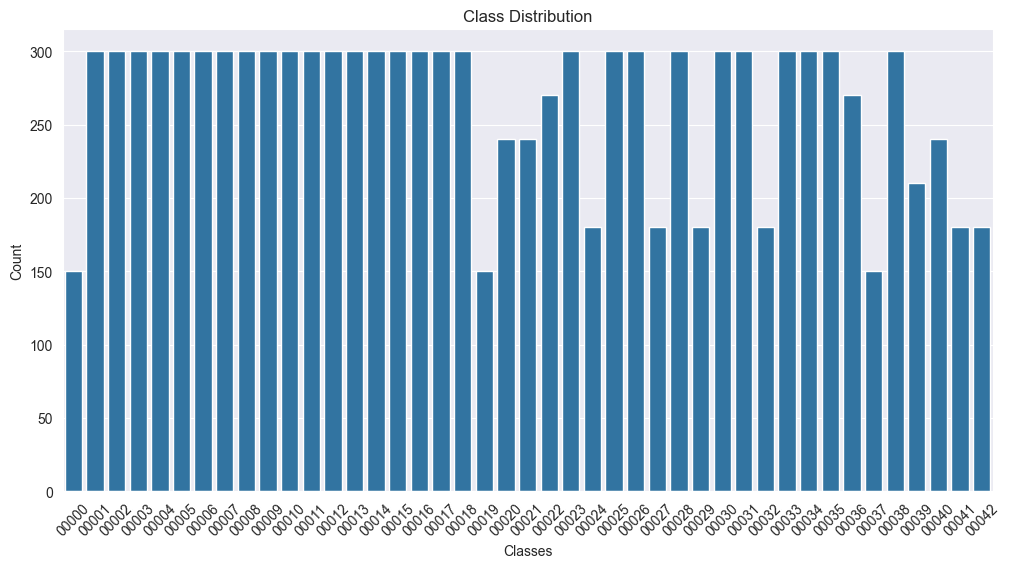

In [14]:
df_counts = pd.DataFrame({
    "class": class_counts.keys(),
    "count": class_counts.values(),
})

plt.figure(figsize=(12, 6))
sns.barplot(x="class", y="count", data=df_counts)
plt.xticks(rotation=45)
plt.xlabel("Classes"), plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

## Global description CSV

In [10]:
dfs = []

for class_path in processed_data_path.iterdir():
    if not class_path.is_dir():
        continue

    csv_file = next(class_path.glob("*.csv"))

    df = pd.read_csv(csv_file, sep=",")

    df["File_path"] = df["Filename"].apply(lambda x: str(class_path / x))

    dfs.append(df)

global_df = pd.concat(dfs, ignore_index=True)

In [12]:
global_df.head()

,Filename,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,File_path
0,00000_00000.ppm,29,30,5,6,24,25,0,F:\Software\Dataspell\TrafficSigns\Data\Proces...
1,00000_00001.ppm,30,30,5,5,25,25,0,F:\Software\Dataspell\TrafficSigns\Data\Proces...
2,00000_00002.ppm,30,30,5,5,25,25,0,F:\Software\Dataspell\TrafficSigns\Data\Proces...
3,00000_00003.ppm,31,31,5,5,26,26,0,F:\Software\Dataspell\TrafficSigns\Data\Proces...
4,00000_00004.ppm,30,32,5,6,25,26,0,F:\Software\Dataspell\TrafficSigns\Data\Proces...


In [24]:
global_df.to_csv(constants.ALL_IMAGES_CSV_PATH, index=False)

## Train/Val/Test split CSVs

In [16]:
df = global_df.sort_values(by=['ClassId', 'Filename']).reset_index(drop=True)

train_list = []
val_list = []
test_list = []

for class_id, group in df.groupby('ClassId'):
    tracks = [group.iloc[i : i + constants.TRACK_LENGTH] for i in range(0, len(group), constants.TRACK_LENGTH)]

    random.shuffle(tracks)

    test_list.append(tracks[0])
    val_list.append(tracks[1])

    remaining_tracks = pd.concat(tracks[2:])
    train_list.append(remaining_tracks)

train_df = pd.concat(train_list).reset_index(drop=True)
val_df = pd.concat(val_list).reset_index(drop=True)
test_df = pd.concat(test_list).reset_index(drop=True)

In [25]:
train_df.to_csv(constants.TRAIN_CSV_PATH, index=False)
test_df.to_csv(constants.TEST_CSV_PATH, index=False)
val_df.to_csv(constants.VAL_CSV_PATH, index=False)